Risk_Label 인코딩 완료
Risk_Label
0    3617
1     491
Name: count, dtype: int64
Valid set: 1438개
Test set:  822개
기대 위반 횟수: 41.1회

비교 기준 확인
Violation 기준: return_t1(%) < GJR_VaR_5_t1
Valid 기간: 2016-11-25 ~ 2022-10-14
Test 기간 : 2022-10-17 ~ 2026-02-26

b1, b2 grid search 중...

Grid Search 결과 (Valid)
최적 b1      = 0.000
최적 b2      = 0.120
Valid 위반율 = 0.0501
Valid p-value= 0.9131
기대 위반율  = 0.0500


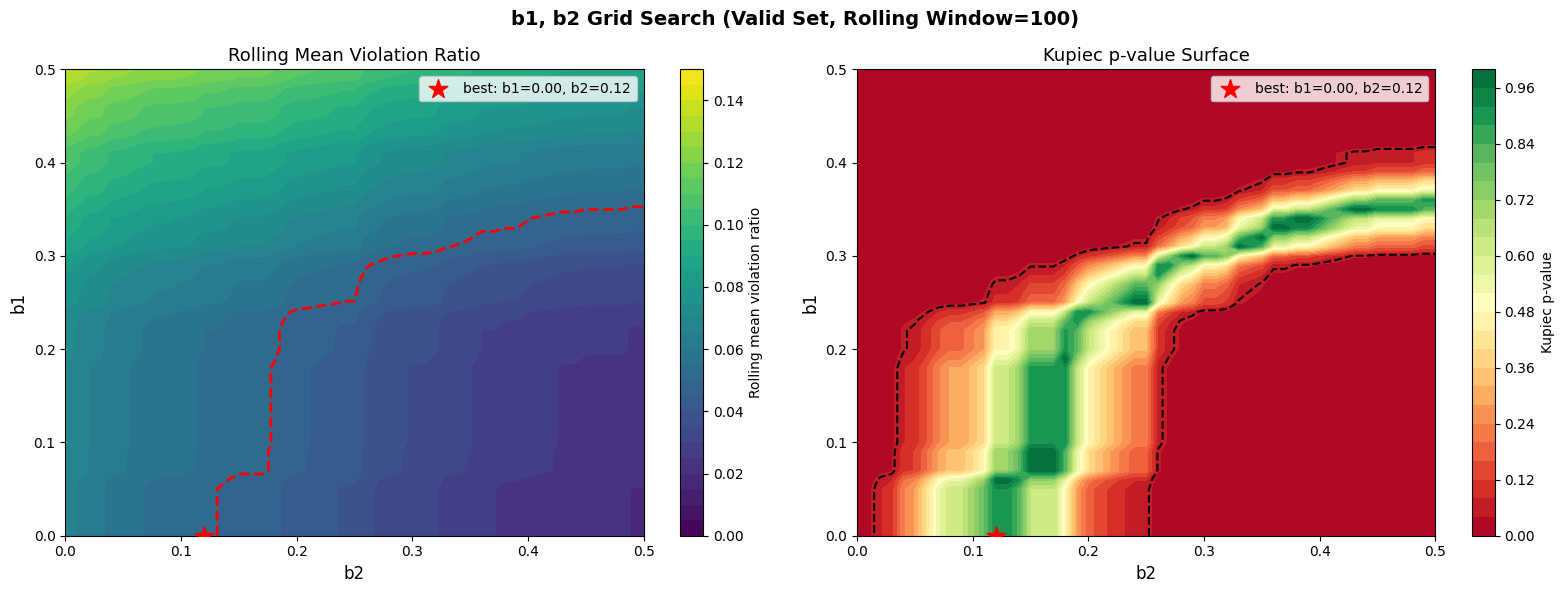


VaR 백테스트 비교 결과
적용 파라미터: b1=0.000, b2=0.120
기대 위반 횟수: 41.1회 (822일 × 5%)
    Model  Violations  Violation Rate  Kupiec p    Kupiec  Ind p   CC p        CC
GJR-GARCH          52          0.0633    0.0932 Accept H0 0.3463 0.1569 Accept H0
       LR          46          0.0560    0.4412 Accept H0 0.3808 0.5063 Accept H0
      SVM          47          0.0572    0.3555 Accept H0 0.4259 0.4753 Accept H0
      ANN          47          0.0572    0.3555 Accept H0 0.4259 0.4753 Accept H0
      MLP          46          0.0560    0.4412 Accept H0 0.3808 0.5063 Accept H0
     DDQN          43          0.0523    0.7627 Accept H0 0.0903 0.2276 Accept H0


C:\Users\dddhs\AppData\Local\Temp\ipykernel_24036\4006952985.py:433: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(model_names, rotation=15)
C:\Users\dddhs\AppData\Local\Temp\ipykernel_24036\4006952985.py:451: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(model_names, rotation=15)


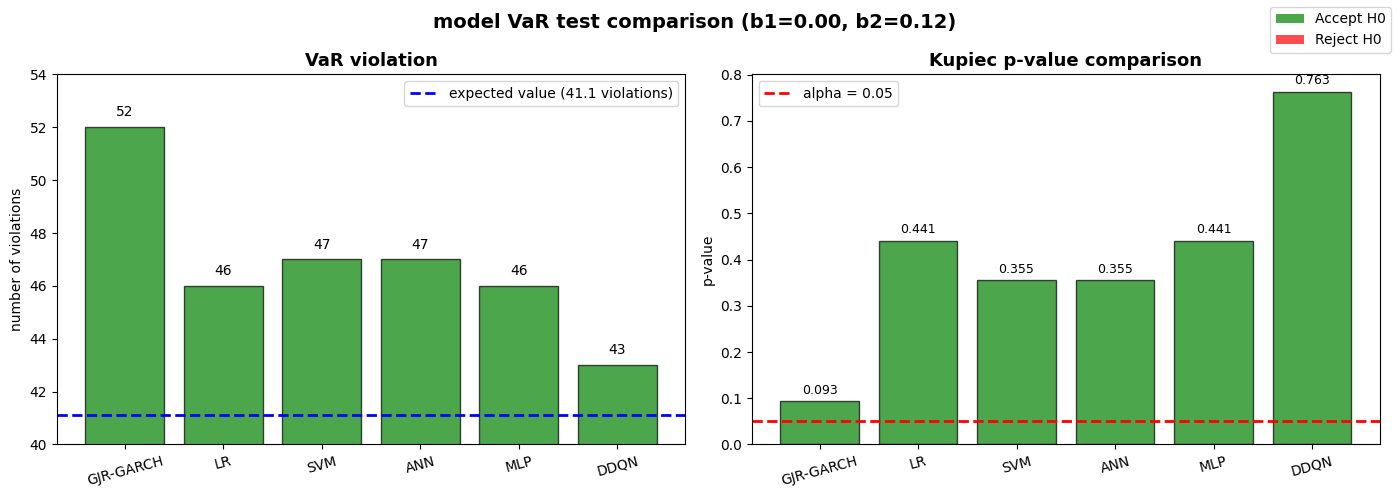

C:\Users\dddhs\AppData\Local\Temp\ipykernel_24036\4006952985.py:496: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax3.set_xticklabels(model_names, rotation=15)


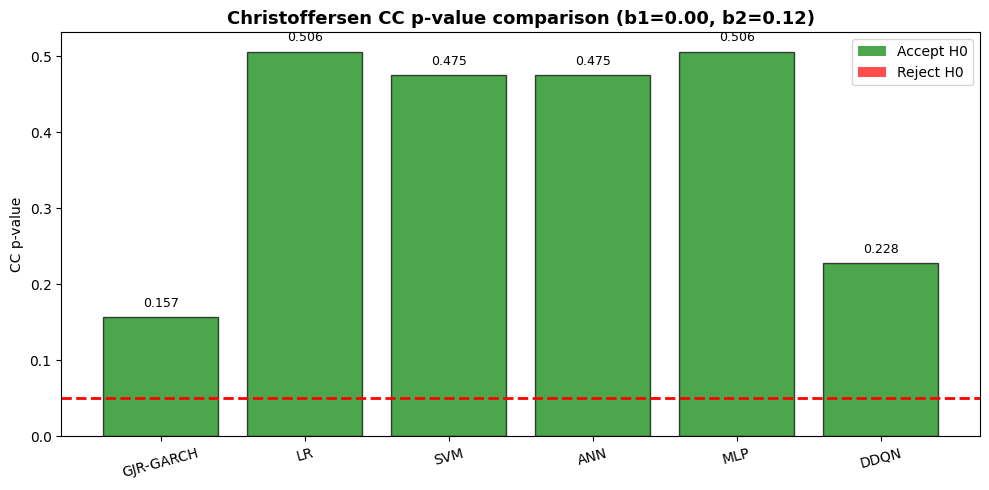

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# =============================================
# Kupiec test
# =============================================
def kupiec_test(violations, n_obs, alpha=0.05):
    T = int(violations)
    N = int(n_obs)
    if T == 0 or T == N:
        return np.nan, np.nan, "계산불가"
    p_hat = T / N
    lr_stat = -2 * (
        T * np.log(alpha / p_hat) +
        (N - T) * np.log((1 - alpha) / (1 - p_hat))
    )
    p_value = 1 - stats.chi2.cdf(lr_stat, df=1)
    decision = "Accept H0" if p_value >= 0.05 else "Reject H0"
    return float(lr_stat), float(p_value), decision


# =============================================
# Christoffersen test
# =============================================
def christoffersen_test(violations_series, alpha=0.05):
    """
    Parameters:
        violations_series: 위반 여부 시계열 (0/1 배열)
        alpha: 유의수준
    
    Returns:
        lr_uc:   Unconditional Coverage 통계량 (Kupiec)
        pv_uc:   UC p-value
        lr_ind:  Independence 통계량
        pv_ind:  Independence p-value
        lr_cc:   Conditional Coverage 통계량
        pv_cc:   CC p-value
        dec_cc:  최종 판정
    """
    I = np.array(violations_series, dtype=int)
    T = len(I)
    n_violations = I.sum()

    # 상태 전이 횟수 계산
    n00 = np.sum((I[:-1] == 0) & (I[1:] == 0))
    n01 = np.sum((I[:-1] == 0) & (I[1:] == 1))
    n10 = np.sum((I[:-1] == 1) & (I[1:] == 0))
    n11 = np.sum((I[:-1] == 1) & (I[1:] == 1))

    # 전이 확률
    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi   = (n01 + n11) / (n00 + n01 + n10 + n11) \
           if (n00 + n01 + n10 + n11) > 0 else 0

    # Unconditional Coverage (Kupiec과 동일)
    p_hat = n_violations / T
    if p_hat == 0 or p_hat == 1:
        lr_uc, pv_uc = np.nan, np.nan
    else:
        lr_uc = -2 * (
            n_violations * np.log(alpha / p_hat) +
            (T - n_violations) * np.log((1 - alpha) / (1 - p_hat))
        )
        pv_uc = 1 - stats.chi2.cdf(lr_uc, df=1)

    # Independence
    if pi == 0 or pi == 1 or pi01 == 0 or pi11 == 0:
        lr_ind, pv_ind = np.nan, np.nan
    else:
        L_ind = (
            (1 - pi01) ** n00 * pi01 ** n01 *
            (1 - pi11) ** n10 * pi11 ** n11
        )
        L_null = (1 - pi) ** (n00 + n10) * pi ** (n01 + n11)

        if L_null == 0 or L_ind == 0:
            lr_ind, pv_ind = np.nan, np.nan
        else:
            lr_ind = -2 * np.log(L_null / L_ind)
            pv_ind = 1 - stats.chi2.cdf(lr_ind, df=1)

    # Conditional Coverage
    if np.isnan(lr_uc) or np.isnan(lr_ind):
        lr_cc, pv_cc = np.nan, np.nan
        dec_cc = "계산불가"
    else:
        lr_cc  = lr_uc + lr_ind
        pv_cc  = 1 - stats.chi2.cdf(lr_cc, df=2)
        dec_cc = "Accept H0" if pv_cc >= 0.05 else "Reject H0"

    return (
        float(lr_uc)  if not np.isnan(lr_uc)  else np.nan,
        float(pv_uc)  if not np.isnan(pv_uc)  else np.nan,
        float(lr_ind) if not np.isnan(lr_ind) else np.nan,
        float(pv_ind) if not np.isnan(pv_ind) else np.nan,
        float(lr_cc)  if not np.isnan(lr_cc)  else np.nan,
        float(pv_cc)  if not np.isnan(pv_cc)  else np.nan,
        dec_cc
    )

# =============================================
# 1. 데이터 로드 및 분할
# =============================================
# b1, b2 선택/백테스트는 VaR_{t+1}와 실제 r_{t+1}를 비교해야 하므로
# return_t1(%)가 남아 있는 data_final.csv를 사용
df = pd.read_csv("../../data/processed/data_final.csv", index_col=0)

# Date index 정리
df.index = pd.to_datetime(df.index)
df = df.sort_index()

# Risk_Label 인코딩
label_raw = df["Risk_Label"].copy()

# 이미 숫자형이면 그대로 int 변환
if pd.api.types.is_numeric_dtype(label_raw):
    df["Risk_Label"] = label_raw.astype(int)

# 문자형이면 robust하게 변환
else:
    label_clean = (
        label_raw
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("_", " ", regex=False)
        .str.replace("-", " ", regex=False)
    )

    df["Risk_Label"] = label_clean.map({
        "low risk": 0,
        "lowrisk": 0,
        "low": 0,
        "0": 0,
        "high risk": 1,
        "highrisk": 1,
        "high": 1,
        "1": 1
    })

    if df["Risk_Label"].isna().any():
        print("Risk_Label 변환 실패 값:")
        print(label_raw[df["Risk_Label"].isna()].value_counts(dropna=False))
        raise ValueError("Risk_Label 인코딩 실패. 위 값을 label_map에 추가해야 함.")

    df["Risk_Label"] = df["Risk_Label"].astype(int)

print("Risk_Label 인코딩 완료")
print(df["Risk_Label"].value_counts())

# 필요한 컬럼 확인
required_cols = ["GJR_VaR_5_t1", "return_t1(%)", "Risk_Label"]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"필요한 컬럼이 없습니다: {missing_cols}")

# train / valid / test = 45 / 35 / 20
n_total   = len(df)
train_end = int(n_total * 0.45)
valid_end = int(n_total * 0.80)

df_valid = df.iloc[train_end:valid_end].copy()
df_test  = df.iloc[valid_end:].copy()

# VaR_{t+1}
var_valid = df_valid["GJR_VaR_5_t1"].to_numpy(dtype=float)
var_test  = df_test["GJR_VaR_5_t1"].to_numpy(dtype=float)

# 실제 r_{t+1}
ret_valid = df_valid["return_t1(%)"].to_numpy(dtype=float)
ret_test  = df_test["return_t1(%)"].to_numpy(dtype=float)

# 실제 Risk_Label: 0=Low Risk, 1=High Risk
action_valid = df_valid["Risk_Label"].to_numpy(dtype=int)
action_test  = df_test["Risk_Label"].to_numpy(dtype=int)

n_valid_len = len(df_valid)
n_test      = len(df_test)

print(f"Valid set: {len(df_valid)}개")
print(f"Test set:  {n_test}개")
print(f"기대 위반 횟수: {n_test * 0.05:.1f}회")

print("\n비교 기준 확인")
print("Violation 기준: return_t1(%) < GJR_VaR_5_t1")
print("Valid 기간:", df_valid.index.min().date(), "~", df_valid.index.max().date())
print("Test 기간 :", df_test.index.min().date(), "~", df_test.index.max().date())

# =============================================
# 2. 모델 예측값 CSV 경로 및 컬럼명 설정
# =============================================
# 컬럼명은 본인 CSV에 맞게 수정하세요
model_configs = {
    "LR":   {"path": "../../results/results_ML/01. LR_test_pred.csv",   "col": "LR_Pred"},
    "SVM":  {"path": "../../results/results_ML/02. SVM_test_pred.csv",  "col": "SVM_Pred"},
    "ANN":  {"path": "../../results/results_ML/03. ANN_test_pred.csv",  "col": "ANN_Pred"},
    "MLP":  {"path": "../../results/results_ML/04. MLP_test_pred.csv",  "col": "MLP_Pred"},
    "DDQN": {"path": "../../results/results_RL/DDQN_predicted_G2.csv", "col": "Predicted_Action"},
}

# =============================================
# 3. b1, b2 grid search (valid에서, 한 번만)
# =============================================
b1_grid     = np.linspace(0.0, 0.5, 51)
b2_grid     = np.linspace(0.0, 0.5, 51)
window_size = 100
n_valid_len = len(df_valid)

coverage      = np.zeros((len(b1_grid), len(b2_grid)))
pvalue_matrix = np.zeros((len(b1_grid), len(b2_grid)))
loss_matrix   = np.zeros((len(b1_grid), len(b2_grid)))

print("\nb1, b2 grid search 중...")

for i, b1 in enumerate(b1_grid):
    for j, b2 in enumerate(b2_grid):

        var_ml = np.where(
            action_valid == 0,
            var_valid * (1.0 - b1),
            var_valid * (1.0 + b2)
        )

        # rolling window 평균 위반율
        rolling_ratios = []
        for start in range(n_valid_len - window_size + 1):
            end   = start + window_size
            ratio = (ret_valid[start:end] < var_ml[start:end]).mean()
            rolling_ratios.append(ratio)

        mean_ratio        = float(np.mean(rolling_ratios))
        coverage[i, j]    = mean_ratio
        loss_matrix[i, j] = abs(mean_ratio - 0.05
                                )

        T_valid = int((ret_valid < var_ml).sum())
        _, pval, _ = kupiec_test(T_valid, n_valid_len)
        pvalue_matrix[i, j] = pval if not np.isnan(pval) else 0.0
min_loss = loss_matrix.min()
candidate_mask = loss_matrix <= (min_loss + 1e-9)
candidates = np.argwhere(candidate_mask)

# 후보들의 Valid CC p-value 계산
best_cc_p = -1
best_candidate = None

for idx in candidates:
    i, j = idx
    b1_val = b1_grid[i]
    b2_val = b2_grid[j]

    var_ml_cand = np.where(
        action_valid == 0,
        var_valid * (1.0 - b1_val),
        var_valid * (1.0 + b2_val)
    )

    I_cand = (ret_valid < var_ml_cand).astype(int)
    _, _, _, _, _, pv_cc_cand, _ = christoffersen_test(I_cand)

    if not np.isnan(pv_cc_cand) and pv_cc_cand > best_cc_p:
        best_cc_p = pv_cc_cand
        best_candidate = (i, j)

best_idx = best_candidate
b1_best = float(b1_grid[best_idx[0]])
b2_best = float(b2_grid[best_idx[1]])
best_ratio   = float(coverage[best_idx])
best_pvalue  = float(pvalue_matrix[best_idx])

print(f"\n{'='*50}")
print("Grid Search 결과 (Valid)")
print(f"{'='*50}")
print(f"최적 b1      = {b1_best:.3f}")
print(f"최적 b2      = {b2_best:.3f}")
print(f"Valid 위반율 = {best_ratio:.4f}")
print(f"Valid p-value= {best_pvalue:.4f}")
print(f"기대 위반율  = 0.0500")

# =============================================
# 4. Contour plot
# =============================================
B2, B1 = np.meshgrid(b2_grid, b1_grid)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 왼쪽: Rolling mean violation ratio ---
ax1 = axes[0]
levels = np.linspace(0.0, 0.15, 31)
cont1 = ax1.contourf(B2, B1, coverage, levels=levels, cmap="viridis")
plt.colorbar(cont1, ax=ax1, label="Rolling mean violation ratio")
ax1.contour(
    B2, B1, coverage,
    levels=[0.05],
    colors="red", linewidths=2, linestyles="--"
)
ax1.scatter(
    [b2_best], [b1_best],
    c="red", s=200, zorder=5, marker="*",
    label=f"best: b1={b1_best:.2f}, b2={b2_best:.2f}"
)
ax1.set_xlabel("b2", fontsize=12)
ax1.set_ylabel("b1", fontsize=12)
ax1.set_title("Rolling Mean Violation Ratio", fontsize=13)
ax1.legend(fontsize=10)

# --- 오른쪽: Kupiec p-value surface ---
ax2 = axes[1]
cont2 = ax2.contourf(B2, B1, pvalue_matrix, levels=30, cmap="RdYlGn")
plt.colorbar(cont2, ax=ax2, label="Kupiec p-value")
ax2.contour(
    B2, B1, pvalue_matrix,
    levels=[0.05],
    colors="black", linewidths=1.5, linestyles="--"
)
ax2.scatter(
    [b2_best], [b1_best],
    c="red", s=200, zorder=5, marker="*",
    label=f"best: b1={b1_best:.2f}, b2={b2_best:.2f}"
)
ax2.set_xlabel("b2", fontsize=12)
ax2.set_ylabel("b1", fontsize=12)
ax2.set_title("Kupiec p-value Surface", fontsize=13)
ax2.legend(fontsize=10)

plt.suptitle(
    f"b1, b2 Grid Search (Valid Set, Rolling Window={window_size})",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

# =============================================
# 5. 모든 모델 한 번에 비교
# =============================================
results = []

T_orig            = int((ret_test < var_test).sum())
lr_o, pv_o, dec_o = kupiec_test(T_orig, n_test)
I_orig = (ret_test < var_test).astype(int)
_, _, lr_ind_o, pv_ind_o, lr_cc_o, pv_cc_o, dec_cc_o = \
    christoffersen_test(I_orig)

results.append({
    "Model":          "GJR-GARCH",
    "Violations":     T_orig,
    "Violation Rate": round(T_orig / n_test, 4),
    "Kupiec p":       round(pv_o,     4) if not np.isnan(pv_o)     else "-",
    "Kupiec":         dec_o,
    "Ind p":          round(pv_ind_o, 4) if not np.isnan(pv_ind_o) else "-",
    "CC p":           round(pv_cc_o,  4) if not np.isnan(pv_cc_o)  else "-",
    "CC":             dec_cc_o,
})

# 각 모델별
for model_name, config in model_configs.items():
    try:
        df_pred     = pd.read_csv(config["path"])
        action_test = df_pred[config["col"]].to_numpy(dtype=int)

        if len(action_test) != n_test:
            print(f"[경고] {model_name}: 길이 불일치 "
                  f"({len(action_test)} vs {n_test})")
            continue

        var_ml_test = np.where(
            action_test == 0,
            var_test * (1.0 - b1_best),
            var_test * (1.0 + b2_best)
        )

        T_ml              = int((ret_test < var_ml_test).sum())
        lr_m, pv_m, dec_m = kupiec_test(T_ml, n_test)
        I_ml = (ret_test < var_ml_test).astype(int)
        _, _, lr_ind_m, pv_ind_m, lr_cc_m, pv_cc_m, dec_cc_m = \
            christoffersen_test(I_ml)

        results.append({
            "Model":          model_name,
            "Violations":     T_ml,
            "Violation Rate": round(T_ml / n_test, 4),
            "Kupiec p":       round(pv_m,     4) if not np.isnan(pv_m)     else "-",
            "Kupiec":         dec_m,
            "Ind p":          round(pv_ind_m, 4) if not np.isnan(pv_ind_m) else "-",
            "CC p":           round(pv_cc_m,  4) if not np.isnan(pv_cc_m)  else "-",
            "CC":             dec_cc_m,
        })

    except FileNotFoundError:
        print(f"[경고] {model_name}: 파일 없음 → {config['path']}")

# =============================================
# 6. 결과 테이블 출력
# =============================================
df_results = pd.DataFrame(results)

print("\n" + "="*70)
print(f"VaR 백테스트 비교 결과")
print(f"적용 파라미터: b1={b1_best:.3f}, b2={b2_best:.3f}")
print(f"기대 위반 횟수: {n_test * 0.05:.1f}회 ({n_test}일 × 5%)")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)

# =============================================
# 7. 결과 시각화 (막대 그래프)
# =============================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = df_results["Model"].tolist()
violations  = df_results["Violations"].tolist()
pvalues     = [v if isinstance(v, float) else 0 
               for v in df_results["Kupiec p"].tolist()]
colors      = ["green" if d == "Accept H0" else "red" 
               for d in df_results["Kupiec"].tolist()]

# 위반 횟수 막대
ax1 = axes[0]
bars = ax1.bar(model_names, violations, color=colors, alpha=0.7, edgecolor="black")
ax1.axhline(
    y=n_test * 0.05, color="blue",
    linestyle="--", linewidth=2, label=f"expected value ({n_test*0.05:.1f} violations)"
)
y_min = min(violations) - 3
y_max = max(violations) + 2
ax1.set_ylim(y_min, y_max)
ax1.set_title("VaR violation", fontsize=13, fontweight="bold")
ax1.set_ylabel("number of violations")
ax1.set_xticklabels(model_names, rotation=15)
ax1.legend()
for bar, val in zip(bars, violations):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        str(val), ha="center", va="bottom", fontsize=10
    )

# p-value 막대
ax2 = axes[1]
bars2 = ax2.bar(model_names, pvalues, color=colors, alpha=0.7, edgecolor="black")
ax2.axhline(
    y=0.05, color="red",
    linestyle="--", linewidth=2, label="alpha = 0.05"
)
ax2.set_title("Kupiec p-value comparison", fontsize=13, fontweight="bold")
ax2.set_ylabel("p-value")
ax2.set_xticklabels(model_names, rotation=15)
ax2.legend()
for bar, val in zip(bars2, pvalues):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.01,
        f"{val:.3f}", ha="center", va="bottom", fontsize=9
    )

# 범례 (초록=Accept, 빨강=Reject)
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green", alpha=0.7, label="Accept H0"),
    Patch(facecolor="red",   alpha=0.7, label="Reject H0"),
]
fig.legend(
    handles=legend_elements,
    loc="upper right", fontsize=10
)

plt.suptitle(
    f"model VaR test comparison (b1={b1_best:.2f}, b2={b2_best:.2f})",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()


# 기존 섹션 7 아래에 추가
fig2, ax3 = plt.subplots(figsize=(10, 5))

cc_pvalues = [v if isinstance(v, float) else 0
              for v in df_results["CC p"].tolist()]
cc_colors  = ["green" if d == "Accept H0" else "red"
              for d in df_results["CC"].tolist()]

bars3 = ax3.bar(model_names, cc_pvalues,
                color=cc_colors, alpha=0.7, edgecolor="black")
ax3.axhline(y=0.05, color="red", linestyle="--",
            linewidth=2, label="alpha = 0.05")
ax3.set_title(
    f"Christoffersen CC p-value comparison (b1={b1_best:.2f}, b2={b2_best:.2f})",
    fontsize=13, fontweight="bold"
)
ax3.set_ylabel("CC p-value")
ax3.set_xticklabels(model_names, rotation=15)
ax3.legend()
for bar, val in zip(bars3, cc_pvalues):
    ax3.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.01,
        f"{val:.3f}", ha="center", va="bottom", fontsize=9
    )

legend_elements2 = [
    Patch(facecolor="green", alpha=0.7, label="Accept H0"),
    Patch(facecolor="red",   alpha=0.7, label="Reject H0"),
]
ax3.legend(handles=legend_elements2)
plt.tight_layout()
plt.show()